# CASR: Sensitivity Scaling Decoherence w/Conventional Spectroscopy

#### Used to investigate how sensitivity scales with interrogation time in presence of dephasing w/conventional spectroscopy
Runs the fig4a ("quantum amplification doesn't win") simulations for the CASR+QVSA+QA paper.

Last updated: 2025/11/13

In [19]:
### IMPORTANT FILE CONFIGURATION ###
# _SAVE_PATH = "Z:\\motion\\Simulation\\Qutip\\CASR Simulations - Clayton\\Results";
# _SAVE_PATH = "/Volumes/groups/motion/Simulation/Qutip/CASR Simulations - Clayton/Results";
_SAVE_PATH = "/Users/claytonho/Documents/Research/Projects/Correlation Sampling/Simulation Data";

## 1 - Setup

### Setup.Imports

In [20]:
### IMPORTS ###
# basic/configuration packages
import os
import sys
import csv
import time
import timeit

# processing packages
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import display, HTML # used to display e.g. panda dataframes

# qutip packages
import qutip
from qutip import *
import qutip.ipynbtools
from qutip import parallel
# from qt_slurm import parallel_slurm as pqt

# data saving & loading - use artiq's RID counter
from artiq.master.rid_counter import RIDCounter

### Setup.Constants

In [21]:
### UNITS ###
ms = 1e-3;
us = 1e-6;
ns = 1e-9;

MHz = 1e6;
kHz = 1e3;
Hz = 1.;

wmhz = 2.*np.pi * 1e6;
wkhz = 2.*np.pi * 1e3;
whz = 2.*np.pi;


### FUNDAMENTAL CONSTANTS ###
debye = 3.3e-30;   #*2/3/1.5; # C/m  factor 2 is due to Bfield is 45 and 45 degree two 1/sqrt(2) away from quantization axis 
hbar = 6.62607015e-34/(2*np.pi);
amu = 1.6605*1e-27; #kg
charge_e = 1.60217663e-19; # C

### Setup.Saving & Loading

In [22]:
### DATA SAVING & RID MODULE ###
# get path to last_rid.pyon in target save directory
_last_rid_path = os.path.join(_SAVE_PATH, "last_rid.pyon");
# create RID counter from artiq.master.RIDCounter to tag saved datasets
rid_counter = RIDCounter(_last_rid_path);


In [23]:
### Qobj saving function ###
def save_qobj_results(qobj_dataset=None, parameters_dataframe=None, save_path=None, rid_num=None):
    """
    todo: document
    :param qobj_dataset: todo: document
    :param parameters_dataframe: todo: document
    :param save_path: todo: document
    """
    # attempt to get save path
    if save_path is None:
        try:
            save_path = _SAVE_PATH
        except Exception as e:
            raise e
    # check target save path exists
    if not os.path.exists(save_path):
        raise Exception("invalid save path")

    # format file name and save directory
    time_current = time.localtime()
    file_dir = os.path.join(
        save_path,
        time.strftime("%Y-%m", time_current),
        # time.strftime("%Y-%m-%d", time_current)
    )
    os.makedirs(file_dir, exist_ok=True)

    
    # check RID number to ensure we don't overwrite existing datasets
    if rid_num is None: rid_num = rid_counter.get()
    while True:
        result_name = "{:05}-{}".format(rid_num, "Simulation Result")
        result_path = os.path.join(file_dir, result_name)
        if not os.path.exists(result_path + ".qu"):
            break
        else:
            rid_num = rid_counter.get()

    # attempt to save qobj dataset and parameters
    if qobj_dataset is not None: qsave(qobj_dataset, result_path)
    if parameters_dataframe is not None:
        param_name = "{:05}-{}.csv".format(rid_num, "Simulation Parameters")
        param_path = os.path.join(file_dir, param_name)
        parameters_dataframe.to_csv(param_path)

    return rid_num


In [24]:
def save_csv(dataset, save_name, save_path=None, rid_num=None):
    """
    todo: document
    :param dataset: todo: document
    :param save_name: todo: document
    :param save_path: todo: document
    """
    # attempt to get save path
    if save_path is None:
        try:
            save_path = _SAVE_PATH
        except Exception as e:
            raise e
    # check target save path exists
    if not os.path.exists(save_path):
        raise Exception("Invalid save path.")

    # format file name and save directory
    time_current = time.localtime()
    file_dir = os.path.join(
        save_path,
        time.strftime("%Y-%m", time_current),
        # time.strftime("%Y-%m-%d", time_current)
    )
    os.makedirs(file_dir, exist_ok=True)

    
    # check RID number to ensure we don't overwrite existing datasets
    if rid_num is None: rid_num = rid_counter.get()
    while True:
        filename_dj = "{:05}-{}.csv".format(rid_num, save_name)
        param_path = os.path.join(file_dir, filename_dj)
        if not os.path.exists(param_path + ""):
            break
        else:
            rid_num = rid_counter.get()

    # attempt to save parameters
    np.savetxt(param_path, dataset, delimiter=',')
    return rid_num


In [25]:
# loading example
# warning - need to have double backslashes otherwise booboo
# fpdefas=os.path.join('Z:\\motion\\Simulation\\Qutip\\Subharmonic Simulations - Clayton\\Results\\2024-09\\2024-09-15\\000888004-Simulation Result');
# kka0 = qload(fpdefas)    time_current = time.localtime()

### Setup.Useful Functions

In [26]:
### FITTING FUNCTIONS ###

def sinc_func(x, a, b, c, d):
    """
    Generalized sinc function.
    todo: document arguments
    """
    # note: numpy's sinc function is defined as sin(pi*x)/(pi*x)
    return a * np.sinc((1.*c) * (x - b) + 1e-7)**2. + d


def fitSinc(data):
    """
    Fit Sinc profile to data.

    Arguments:
        ***todo

    Returns:
        ***todo
    """
    # separate data into x and y
    try:
        data =              np.array(data)
        data_x, data_y =    data.transpose()
    except:
        data = np.array(data)
        data_x = data[0,:]
        data_y = data[1,:]

    # guess linecenter as position of max value
    b0 =                np.mean(data_x[np.argwhere(data_y == np.max(data_y))])
    # get offset as min of data
    d0 =                np.min(data_y)
    # get maximum value
    # maxval =            np.max(data_y) - d0
    a0 =                np.max(data_y) - d0
    # guess linewidth by rectifying the data
    c0tmp = data_x[np.argmin(np.abs(data_y - 0.5 * a0))]
    c0 = 1. / (np.abs(c0tmp - b0))
    # print(c0tmp)
    # print(c0)
    # guess amplitude using max y-value with offset subtracted
    # a0 = maxval / (2.* (np.pi*c0)**2.)

    # fit and convert covariance matrix to error (1 stdev)
    param_fit, param_cov =  curve_fit(sinc_func, data_x, data_y, p0=[a0, b0, c0, d0])
    param_err =             np.sqrt(np.diag(param_cov))
    return param_fit, param_err
    

In [27]:
### PROCESSING/GENERAL UTILITIES ###
from random import shuffle
from collections.abc import Iterable
from itertools import product, zip_longest

def flatten_maybe_tuple(xs):
    """
    Use generator to flatten list with SOME tuples.
    """
    for x in xs:
        if isinstance(x, Iterable) and not isinstance(x, (str, bytes)):
            yield from flatten_maybe_tuple(x)
        else:
            yield x

def create_experiment_config(*args, shuffle_config=False):
    """
    Creates a 2D list of experiment configuration values.
    Each row represents a different experiment configuration to run.
    :param args: parameter lists to merge into an experiment config.
    :param shuffle_config: whether to shuffle the configuration list.
    :return: the configured experiment config as a 2D numpy array.
    """
    # create an array of values for the experiment to sweep
    exp_config = [
        list(flatten_maybe_tuple(vals))
        for vals in product(*args)
    ]

    if shuffle_config is True: shuffle(exp_config)
    return exp_config

def riffle(*args):
    """
    Riffles an arbitrary number of arbitrary-length iterables sequentially.
    Iterables can each be of different length.
    :param args: iterables to riffle.
    :return: a tuple of the riffled iterables.
    """
    return tuple(
        y
        for x in zip_longest(*args, fillvalue=None)
        for y in x if y is not None
    )


### Setup.Result Formatting

In [28]:
def plot_spectrum(xaxis_plot_vals, solution_array, rid_num=None, fig_title_string="Scan Results"):
    """
    todo: document
    Note: this function should now work fine by itself - i.e. shouldn't need e.g. external variables to be defined
    :param xaxis_plot_vals: todo: document
    :param solution_array: todo: document
    :param rid_num: todo: document
    :param fig_title_string: todo: document
    """
    # extract relevant points
    res_points = np.array([res_obj.expect[0] for res_obj in solution_array])
    res_lineshape = res_points[:, -1];
    res_lineshape_max = np.max(res_points, axis=-1);
    
    # attempt to fit a sinc to the result
    try:
        fit_results = fitSinc(np.array([xaxis_plot_vals, res_lineshape]).transpose());
    except Exception as e:
        fit_results = np.zeros((2, 4))
    finally:
        fitted_sinc_yvals = np.array([sinc_func(x_val, *fit_results[0]) for x_val in xaxis_plot_vals]);
    
    
    ### PLOT SPECTRUM ###
    # create figure
    fig_spectrum, axs = plt.subplots(1, 1, layout='constrained')
    # fig_title_string = "$\omega_0$ = {:.1f} x 2$\pi$ MHz;\tK = {:.0f};\nRSB: $V_q$ = {:.3g}, $V_d$ = {:.3g};\t\tBSB: $V_q$ = {:.3g}, $V_d$ = {:.3g}".format(
    #     freq_upconverted_hz/wmhz, 2*w0/freq_center_hz, V_q_r, V_d_r, V_q_b, V_d_b,
    # )
    if rid_num is not None:
        fig_title_string = "RID: {:d}\n".format(rid_num) + fig_title_string
    
    # plot raw and fitted results
    axs.plot(xaxis_plot_vals, res_lineshape, 'o--', label='Last');
    #axs[0].plot(x_axis_plot_wkhz, res_lineshape_max, 'o--', label='max', alpha=0.5);
    axs.plot(xaxis_plot_vals, fitted_sinc_yvals, '-', label='Sinc Fit');
    
    # format plot
    axs.set_title(fig_title_string);
    axs.set_ylabel("<n>");
    axs.set_xlabel("Detuning (x2$\pi$ kHz)");
    axs.legend();
    axs.grid(visible=True);
    
    
    ### SHOW PARAMETER TABLE ###
    #axs[1].table(cellText=parameter_df.values, colLabels=parameter_df.keys(), loc='center');
    #axs[1].
    
    ### PRINT HELPER STATISTICS ###
    print("Max <n>:\t{:.3g}".format(fit_results[0][0]));
    print("Linecenter:\t{:.3f} x2pi kHz".format(fit_results[0][1]));
    print("Linewidth:\t{:.3f} ms".format(fit_results[0][2]));
    # return fig_spectrum


<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
/var/folders/v0/b19pywqs3rxglwd__dhlhm2w0000gn/T/ipykernel_30271/2615000596.py:41: SyntaxWarning: invalid escape sequence '\p'
  axs.set_xlabel("Detuning (x2$\pi$ kHz)");


In [29]:
def plot_state(solution_array, rid_num=None, fig_title_string=None):
    """
    todo: document
    Note: this function should now work fine by itself - i.e. shouldn't need e.g. external variables to be defined
    :param solution_array: todo: document
    :param rid_num: todo: document
    :param fig_title_string: todo: document
    """
    # extract relevant points
    res_points = np.array([res_obj.expect[0] for res_obj in solution_array]);
    res_target_ind = np.argmax(res_points[:, -1]);

    # get state vector @ target result index (e.g. linecenter) and create density matrix
    target_soln = res_dj[res_target_ind];
    target_soln_state = target_soln.final_state;
    target_soln_rho = target_soln_state * target_soln_state.dag();
    #soln_vec = np.diagonal(Qobj.full(target_soln_rho));
    #soln_probs = soln_vec * soln_vec.conj().T;

    # calculate wigner function @ linecenter
    num_points_wigner = 100;
    #target_avg_n = expect(n, target_soln_state);
    target_avg_n = Nmax/3.;
    x_wigner_arr = np.linspace(-1., 1., num_points_wigner) * (target_avg_n * 1);
    target_soln_wigner = wigner(target_soln_rho, x_wigner_arr, x_wigner_arr);
    
    # create figure
    fig, axs = plt.subplots(1, 2, layout='constrained');
    if fig_title_string is None:
        fig_title_string = "Motional State @ Target ({:d})".format(res_target_ind)
    if rid_num is not None:
        fig_title_string = "RID: {:d}\n".format(rid_num) + fig_title_string
    fig.suptitle(fig_title_string);
    
    # plot fock state distribution
    axs[0].set_title("Fock State Distribution");
    axs[0].set_yscale('log');
    plot_fock_distribution(target_soln_rho, ax=axs[0]);
    # further configure plotting
    #axes.set_xlim(0, 10)

    # plot wigner function
    cont0 = axs[1].contourf(x_wigner_arr, x_wigner_arr, target_soln_wigner, num_points_wigner);
    axs[1].axhline(y=0, linewidth=2, color='w');
    axs[1].axvline(x=0, linewidth=2, color='w');
    axs[1].set_title("Wigner Distribution");
    axs[1].set_xlabel("$\hat{X}$");
    axs[1].set_ylabel("$\hat{P}$");
    axs[1].grid(visible=True);

    

<>:47: SyntaxWarning: invalid escape sequence '\h'
<>:48: SyntaxWarning: invalid escape sequence '\h'
<>:47: SyntaxWarning: invalid escape sequence '\h'
<>:48: SyntaxWarning: invalid escape sequence '\h'
/var/folders/v0/b19pywqs3rxglwd__dhlhm2w0000gn/T/ipykernel_30271/10529188.py:47: SyntaxWarning: invalid escape sequence '\h'
  axs[1].set_xlabel("$\hat{X}$");
/var/folders/v0/b19pywqs3rxglwd__dhlhm2w0000gn/T/ipykernel_30271/10529188.py:48: SyntaxWarning: invalid escape sequence '\h'
  axs[1].set_ylabel("$\hat{P}$");


In [30]:
def plot_trace(solution_array, rid_num=None, fig_title_string="Sweep Traces"):
    """
    todo: document
    Note: this function should now work fine by itself - i.e. shouldn't need e.g. external variables to be defined
    :param solution_array: todo: document
    :param rid_num: todo: document
    :param fig_title_string: todo: document
    """
    # extract time series & get index of target (e.g. linecenter)
    res_timeseries = np.array([res_obj.expect[0] for res_obj in solution_array])
    target_ind = np.argmax(res_timeseries[:, -1]);

    # create figure
    fig, axs = plt.subplots(1, 1, layout='constrained');

    # plot all time series
    for time_series in res_timeseries:
        # todo: add label
        axs.plot(time_arr_s[:]/us, time_series[:], 'o--');

    # configure plot
    # axs.set_title("$\omega_0$ = {:.1f} x 2$\pi$ MHz;\tK = {:.0f}\t$V_q$ = {:.3g}, $V_d$ = {:.3g}".format(
    #     freq_upconverted_hz/wmhz, 2*w0/freq_center_hz, V_q, V_d)
    #  );
    # fig_title_string = "$\omega_0$ = {:.1f} x 2$\pi$ MHz;\tK = {:.0f};\nRSB: $V_q$ = {:.3g}, $V_d$ = {:.3g};\t\tBSB: $V_q$ = {:.3g}, $V_d$ = {:.3g}".format(
    #     freq_upconverted_hz/wmhz, 2*w0/freq_center_hz, V_q_r, V_d_r, V_q_b, V_d_b,
    # );
    axs.set_title(fig_title_string);
    axs.set_xlabel("Time ($\mu$s)");
    axs.set_ylabel("<n>");
    #plt.legend()


<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
/var/folders/v0/b19pywqs3rxglwd__dhlhm2w0000gn/T/ipykernel_30271/2808679060.py:29: SyntaxWarning: invalid escape sequence '\m'
  axs.set_xlabel("Time ($\mu$s)");


In [31]:
def show_parameters(param_list):
    """
    todo: document
    Note: this function should now work fine by itself - i.e. shouldn't need e.g. external variables to be defined
    :param param_list: todo: document
    """
    # convert parameter list into a dataframe
    param_df = pd.DataFrame(param_list, columns=["Parameter", "Value", "Units"]);
    
    # create figure and show parameters
    fig_params, axs = plt.subplots(1, 1, layout='constrained')
    axs.table(cellText=parameter_df.values, colLabels=parameter_df.keys(), loc='center', fontsize=28);

    # configure display
    fig_params.suptitle("Simulation Parameters");
    axs.axis('off');

    # tmp - use built-in dataframe display tool
    # display(HTML(param_list.to_html()))


### Setup.SLURM - EXTRA

In [32]:
# #DO NOT RUN THIS ONE

# results = pqt.parallelize(sweep_func, detunings, num_of_divs)
# print(results)

In [33]:
# RUN THIS ONE
'''
This and the first cell that imports all modules are the only cells you need to run to queue a Slurm job
'''
# pqt.execute("Qt_Slurm_Example", 5, 8, 5)

'\nThis and the first cell that imports all modules are the only cells you need to run to queue a Slurm job\n'

## 2 - Prepare Simulation

### Prepare.Sweep Function (for parallelization)

In [34]:
### CREATE SWEEP FUNCTION FOR PARALLELIZATION ###
def parallel_sweep_func(sweep_dict):
    """
    todo: document
    """
    # extract mandatory arguments from sweep_dict
    H_local = sweep_dict.get('H');
    psi0_local = sweep_dict.get('psi0');
    tlist_local = sweep_dict.get('tlist');

    # extract optional arguments from sweep_dict
    e_ops_local = sweep_dict.get('e_ops', None);
    c_ops_local = sweep_dict.get('c_ops', None);
    args_local = sweep_dict.get('args', None);

    # get simulation options
    opts_extra_local = sweep_dict.get('opts_extra', {});

    # define fixed/local stuff
    options_local = {
        'nsteps': 1e6,
        'max_step': tlist_local[-1]/5,
        # 'max_step': t_pulse_ramsey_s/4,
        'store_final_state': True,
        'progress_bar': False,
    }
    for k, v in opts_extra_local.items(): options_local.update({k:v})

    
    ### SOLVE! ###
    # note: should define max_step as > 0.5x pulse time to prevent solver from missing the pulse
    # see here: https://qutip.readthedocs.io/en/qutip-5.0.x/guide/dynamics/dynamics-time.html)
    
    # # schrodinger solve
    # outputc = sesolve(
    #     H_local, psi0_local, tlist_local,
    #     e_ops=e_ops_local, args=args_local,
    #     options=options_local
    # )
    
    # mesolve
    outputc = mesolve(
        H_local, psi0_local, tlist_local,
        e_ops=e_ops_local, c_ops=c_ops_local,
        args=args_local,
        options=options_local
    )
    
    return outputc
    

### Prepare.System

In [67]:
### KEY VARIABLES - ION CHAIN CONFIGURATION ### 
w0 = 1282 * wkhz;
r_0 = 5.5e-4;
bij = 1.;
mass = 40*amu;

### KEY VARIABLES - ION CHAIN - DERIVED VALUES ###
x0 = bij * np.sqrt(hbar/(2. * mass * w0));
eta = x0 / r_0;

### KEY VARIABLES - RABI FREQUENCIES (MOTIONAL) ###
rabi_dipole = eta * (charge_e / hbar); # note: need ~1e-8V for baseband tickle

### KEY VARIABLES - SYSTEM/ENVIRONMENT ###
# specify simulation parameters
Nmax = 50;
num_evolution_points = 200; # number of points to read during evolution

# dephasing etc
gamma_dephasing = 1. / (1000 * us);


### Prepare.Sweep

In [68]:
### CONFIGURE SWEEP VALUES ###
# specify target state parameter - squeezing
state_param_list = np.concatenate([
    # [0, 1, 2, 3, 4, 5],
    # [0, 0.1, 0.2, 0.5, 1.0]
    np.arange(0, 2., 0.1),
]);
state_param_list = np.sort(list(set(state_param_list)));

# specify state displacement parameter/ramsey scanning
state_displ_list = np.concatenate([
    np.arange(0.1, 4, 0.1),
    # [0.4],
]);
state_displ_list = np.sort(list(set(state_displ_list)));

# create detuning sweep array
freq_center_whz = w0 + 0.*wkhz;
freq_sweep_whz = np.concatenate([
    # np.linspace(-1.5, 1.5, 81) * wkhz,
    [0.],
]);
freq_sweep_whz = np.sort(list(set(freq_sweep_whz)));

# specify pulse timings
t_rollon_s = 0*us;
t_pulse_time_list = np.concatenate([
    [5000 * us],
    # np.arange(50, 100, 10) * us,
    # np.arange(100, 1000, 250) * us,
    # np.arange(1000, 5000, 500) * us,
    # np.arange(1000, 5000, 200) * us,
    # np.arange(5000, 10000, 500) * us,
]);
t_pulse_time_list = np.sort(list(set(t_pulse_time_list)));


### COLLATE SWEEPS INTO AN EXPCONFIG FOR EASY SWEEPING ###
sweep_param_list = create_experiment_config(
    freq_sweep_whz, t_pulse_time_list, state_param_list, state_displ_list
);
print("Num. Sweeps:\t{:d}".format(len(sweep_param_list)));

# create dataset labels to aid documentation
sweep_param_labels = ["freq_sweep_khz", "t_pulse_time_list", "state_param_list", "state_displ_list"];
sweep_param_units = ["kHz", "s", "squeeze_sq", "displ_alpha"];
if (len(sweep_param_labels) != len(sweep_param_units)) or (len(sweep_param_labels) != np.shape(sweep_param_list)[1]):
    raise Exception("Sweep metadata and sweep config disagree. pls fix");


# ### TMP - RESCALE THE FREQUENCY AXES FOR 4A SIMS ###
# time_base_s = 1000 * us;
# sp2 = np.array(sweep_param_list);
# sp2[:, 0] *= (time_base_s / sp2[:, 1]);
# sweep_param_list = list(sp2);
# # print(sweep_param_list[:5])
# ### TMP - RESCALE THE FREQUENCY AXES FOR 4A SIMS ###


Num. Sweeps:	780


### Prepare.Implement_Sweep

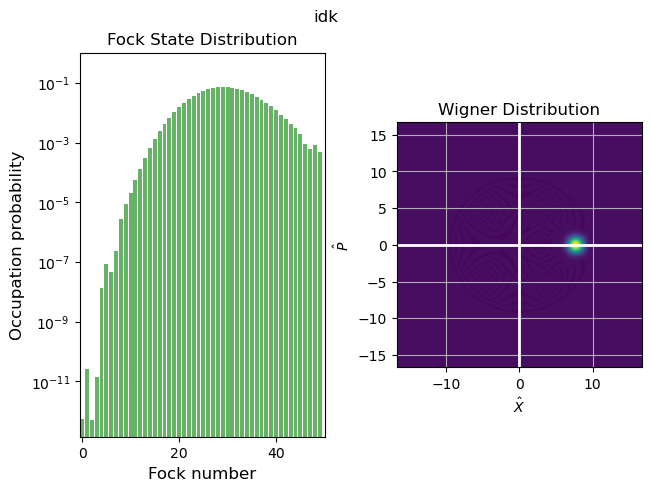

In [70]:
state_squeeze_sq = 1.;
state_coherent_displ = 1.;

# create initial state
state_initial_ket = squeeze(Nmax, state_squeeze_sq) * fock(Nmax, 0);
state_init_sweep = displace(Nmax, state_coherent_displ) * state_initial_ket;
state_contrast_sweep = (displace(Nmax, state_coherent_displ).dag()) * state_initial_ket;

sca = state_init_sweep * state_init_sweep.dag();
scb = state_contrast_sweep * state_contrast_sweep.dag();

# plot_state2(state_init_sweep);
# plot_state2(sca * state_init_sweep);
plot_state2((displace(Nmax, state_coherent_displ).dag() * squeeze(Nmax, state_squeeze_sq)).dag() * state_init_sweep);
# print(np.sum(np.abs(((scb * state_init_sweep).full()))**2.))

In [44]:
def plot_state2(state_vector, rid_num=None, fig_title_string=None):
    """
    todo: document
    Note: this function should now work fine by itself - i.e. shouldn't need e.g. external variables to be defined
    :param solution_array: todo: document
    :param rid_num: todo: document
    :param fig_title_string: todo: document
    """
    target_soln_rho = state_vector * state_vector.dag();

    # calculate wigner function @ linecenter
    num_points_wigner = 100;
    target_avg_n = Nmax/3.;
    x_wigner_arr = np.linspace(-1., 1., num_points_wigner) * (target_avg_n * 1);
    target_soln_wigner = wigner(target_soln_rho, x_wigner_arr, x_wigner_arr);
    
    # create figure
    fig, axs = plt.subplots(1, 2, layout='constrained');
    fig.suptitle("idk");
    
    # plot fock state distribution
    axs[0].set_title("Fock State Distribution");
    axs[0].set_yscale('log');
    plot_fock_distribution(target_soln_rho, ax=axs[0]);
    # further configure plotting
    #axes.set_xlim(0, 10)

    # plot wigner function
    cont0 = axs[1].contourf(x_wigner_arr, x_wigner_arr, target_soln_wigner, num_points_wigner);
    axs[1].axhline(y=0, linewidth=2, color='w');
    axs[1].axvline(x=0, linewidth=2, color='w');
    axs[1].set_title("Wigner Distribution");
    axs[1].set_xlabel("$\hat{X}$");
    axs[1].set_ylabel("$\hat{P}$");
    axs[1].set_aspect("equal");
    axs[1].grid(visible=True);

    

<>:33: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\h'
/var/folders/v0/b19pywqs3rxglwd__dhlhm2w0000gn/T/ipykernel_30271/2461439665.py:33: SyntaxWarning: invalid escape sequence '\h'
  axs[1].set_xlabel("$\hat{X}$");
/var/folders/v0/b19pywqs3rxglwd__dhlhm2w0000gn/T/ipykernel_30271/2461439665.py:34: SyntaxWarning: invalid escape sequence '\h'
  axs[1].set_ylabel("$\hat{P}$");


In [37]:
%%time
### PREPARE SIMULATION DICT ###
# define non-swept values/parameters
voltage_dj = (2.92e-8/2.) / 4; # \alpha=0.4 in 1ms
t_pulse_ramsey_s = 20*us;

# scale relevant variables
voltage_scale_tmp = 1e-8;#(1000 * us) / t_pulse_ramsey_s;#((1000*us) / time_pulse_sweep_s);

# define non-swept operators
ahat = tensor(destroy(Nmax));
nhat = ahat.dag() * ahat;
xhat = ahat.dag() + ahat;


### CREATE SIMULATION DICT ###
# holds the simulation dict for easy sweeping/scanning/parallelization
sweep_config_list = []

# create a sweep_config dict for each simulation that we want to run
for sweep_params in sweep_param_list:
    '''
    BREAK OUT SWEEP PARAMS
    '''
    # extract parameters from sweep_params
    freq_whz_sweep = sweep_params[0];
    time_pulse_sweep_s = sweep_params[1];
    # state_fock_n = int(round(sweep_params[2]));
    state_squeeze_sq = sweep_params[2];
    state_coherent_displ = sweep_params[3];
    
    # create initial state
    # state_initial_ket = fock(Nmax, state_fock_n);
    state_initial_ket = squeeze(Nmax, state_squeeze_sq) * fock(Nmax, 0);
    state_init_sweep = displace(Nmax, state_coherent_displ) * state_initial_ket;
    state_contrast_sweep = (displace(Nmax, state_coherent_displ).dag()) * state_initial_ket;


    '''
    DEFINE HAMILTONIAN & RELEVANT ARGS
    '''   
    # create hamiltonian - RWA
    H_local = [
        [
            voltage_dj * voltage_scale_tmp * rabi_dipole * ahat.dag(),
            'exp(-1j * omega * t + phi)'
            # 'exp(-1j * omega * t + phi) * '
            # '('
            #     'np.heaviside(t - 0, 1) * np.heaviside((0 + t_pulse_ramsey_s) - t, 1) + '
            #     'np.heaviside(t - (time_pulse_sweep_s - t_pulse_ramsey_s), 1) * np.heaviside(time_pulse_sweep_s - t, 1)'
            # ')'
        ], # adag/raising term
        [
            voltage_dj * voltage_scale_tmp * rabi_dipole * ahat,
            'exp(1j * omega * t + phi)'
            # 'exp(1j * omega * t + phi) * '
            # '('
            #     'np.heaviside(t - 0, 1) * np.heaviside((0 + t_pulse_ramsey_s) - t, 1) + '
            #     'np.heaviside(t - (time_pulse_sweep_s - t_pulse_ramsey_s), 1) * np.heaviside(time_pulse_sweep_s - t, 1)'
            # ')'
        ], # a/lowering term
    ];
    # create argument dict to customize hamiltonian - RWA
    args_local = {
        'omega': freq_whz_sweep, ## for RWA
        't_pulse_ramsey_s': t_pulse_ramsey_s,
        'time_pulse_sweep_s': time_pulse_sweep_s,
        'phi': 0.,
    };

    
    '''
    THINGS THAT GENERALLY DON'T NEED CONFIGURING/ADJUSTMENT
    '''
    # create result timestep list
    t_res_sow_local_s = np.linspace(0., time_pulse_sweep_s + 2.*t_rollon_s, num_evolution_points);
    
    # create relevant expectation operators (for readout) and collapse (for lindblad)
    e_ops_local = [
        # nhat, # mean phonon number
        (state_init_sweep * state_init_sweep.dag()), # fwolf fock overlap readout
        (state_contrast_sweep * state_contrast_sweep.dag()), # fwolf fock overlap readout
    ];
    c_ops_local = [
        np.sqrt(gamma_dephasing) * (ahat.dag()*ahat), # pure dephasing operator
    ];

    # create sweep dict!
    dict_local_tmp = {
        "H": H_local,
        "psi0": state_init_sweep,
        "tlist": t_res_sow_local_s,
        "args": args_local,
        "e_ops": e_ops_local,
        "c_ops": c_ops_local,
    };
    
    # update parent holding list
    sweep_config_list.append(dict_local_tmp)

# print number of sweeps to be run
print("Num. Sweeps:\t{:d}".format(len(sweep_config_list)));


Num. Sweeps:	780
CPU times: user 1min 52s, sys: 5.82 s, total: 1min 58s
Wall time: 7.76 s


### Prepare.Parameter Table

In [38]:
### CREATE RESULT PARAMETER TABLE TO BE SAVED WITH SIMULATION RESULTS ###
# extract args from sweep_config_list and save them with the results
sweep_config_arg_list = [dict_tmp["args"] for dict_tmp in sweep_config_list]
sweep_config_arg_keys = set().union(*sweep_config_arg_list)
sweep_config_args_final = dict(zip(
    sweep_config_arg_keys, 
    [
        [dict_tmp.get(k, None)
         for dict_tmp in sweep_config_arg_list]
        for k in sweep_config_arg_keys
    ]
));

# create list of parameters for dataframe/saving with results
parameter_list = [
    ## interaction strengths
    # ['V_quadrupole_RSB', V_q_r, "V"],
    # ['V_dipole_RSB', V_d_r, "V"],

    # system configuration
    ['Secular Freq.', w0/wkhz, "x2pi kHz"],
    ['Tickle Rabi Freq.', rabi_dipole, "idk"],

    # system parameters
    ['N_max.', Nmax, "Phonons"],
    ['Dephasing Time', 1/gamma_dephasing/us, "us"],

    # timing
    # ['Main Pulse Time.', t_pulse_s/us, "us"],
    ['Ramsey Pulse Time.', t_pulse_ramsey_s/us, "us"],
    ['Rollon Time.', t_rollon_s/us, "us"],

    # dataset/meta
    ['Sweep Config Labels', sweep_param_labels, sweep_param_units],

    # expand sweep_config_args_final for parameter_dataframe
    *[[k, v, "idk"] for k, v in sweep_config_args_final.items()]
];

# create dataframe
parameter_df = pd.DataFrame(parameter_list, columns=["Parameter", "Value", "Units"]);


## 3 - Run

### Run.Actual

In [182]:
### EVALUATE SWEEP FUNCTION IN SERIES ###
#res_dj = [parallel_sweep_func(sweep_config_tmp) for sweep_config_tmp in sweep_config_list];
### EVALUATE SWEEP FUNCTION IN PARALLEL ###
res_dj = parallel.loky_pmap(parallel_sweep_func, sweep_config_list, progress_bar=True)

### SAVE RESULTS ###
# rid_saved = save_qobj_results(qobj_dataset=res_dj, parameters_dataframe=parameter_df);
rid_saved = save_qobj_results(qobj_dataset=None, parameters_dataframe=parameter_df);
print("Result RID: {}".format(rid_saved));
save_csv(sweep_param_list, 'sim_sweep_param_list', rid_num=rid_saved);


10.0%. Run time:  19.92s. Est. time left: 00:00:02:59
20.0%. Run time:  34.80s. Est. time left: 00:00:02:19
30.0%. Run time:  51.61s. Est. time left: 00:00:02:00
40.0%. Run time:  66.50s. Est. time left: 00:00:01:39
50.0%. Run time:  81.42s. Est. time left: 00:00:01:21
60.0%. Run time:  96.01s. Est. time left: 00:00:01:04
70.0%. Run time: 111.68s. Est. time left: 00:00:00:47
80.0%. Run time: 126.79s. Est. time left: 00:00:00:31
90.0%. Run time: 140.65s. Est. time left: 00:00:00:15
100.0%. Run time: 154.70s. Est. time left: 00:00:00:00
Total run time: 155.54s
Result RID: 82


## TMP Proc

[[0.  0.1]
 [0.  0.2]
 [0.9 1.9]]
val1: 0.005	val2: 0.0


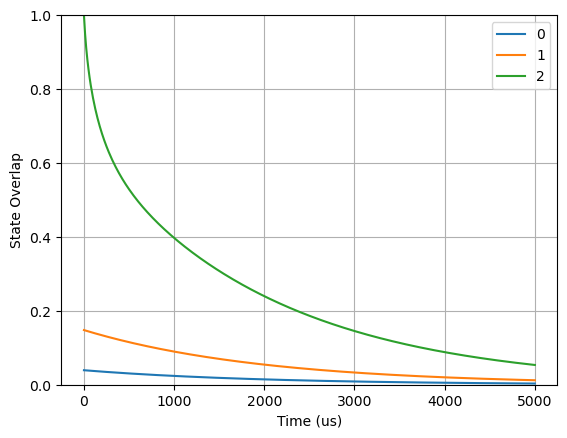

[np.float64(0.9996022675759584), np.float64(0.0005857444089762543)]
Res: [7.5654060e-01 5.8010807e-04]
Err: [4.79113175e-03 5.40224121e-06]


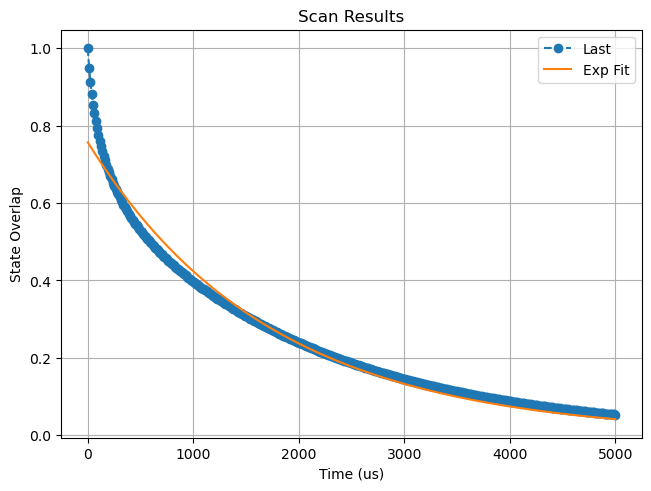

In [129]:
### PROCESS RESULTS ACCORDING TO LOCAL STYLE ###
tha = np.sort(list(set(np.array(sweep_param_list)[:, 1])))[0];
thb = np.sort(list(set(np.array(sweep_param_list)[:, 2])))[0];
# th0 = [
#     [sweep_param_list[idx][0], qutip_res.expect[1][-1]]
#     for idx, qutip_res in enumerate(res_dj)
#     if (sweep_param_list[idx][1] == tha) and (sweep_param_list[idx][2] == thb)
# ];
# th0 = [
#     [sweep_param_list[idx][0], qutip_res.expect[1][-1]]
#     for idx, qutip_res in enumerate(res_dj)
# ];
th0 = [
    [qutip_res.times, np.abs(np.array(qutip_res.expect[0]) - np.array(qutip_res.expect[1]))]
    for idx, qutip_res in enumerate(res_dj)
];
select_idx_dj = [0,1,-1];
th0 = [th0[idx] for idx in select_idx_dj];
print(np.array(sweep_param_list)[select_idx_dj, 2:])

print("val1: {}\tval2: {}".format(tha,thb));
for idx, arr in enumerate(th0):
    th1 = np.array(arr).transpose();
    th1 = th1[np.argsort(th1[:, 0])];
    plt.plot(th1[:,0]/us, th1[:,1], label="{}".format(idx));

plt.ylim([0., 1.]);
plt.ylabel("State Overlap");
plt.xlabel("Time (us)");
plt.legend();
plt.grid(visible=True);
plt.show()
plot_tmp(th1[:,0]/us, th1[:,1]);



### Run.Process & Show (old)


/var/folders/v0/b19pywqs3rxglwd__dhlhm2w0000gn/T/ipykernel_11011/2615000596.py:41: SyntaxWarning: invalid escape sequence '\p'
  axs.set_xlabel("Detuning (x2$\pi$ kHz)");


ValueError: x and y must have same first dimension, but have shapes (1,) and (5,)

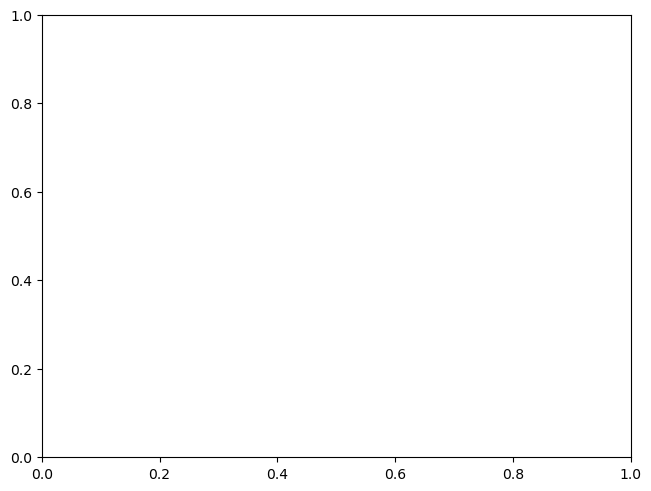

In [80]:
### SHOW SUMMARY RESULTS ###
plot_spectrum(freq_sweep_whz/wkhz, res_dj, rid_num=rid_saved);
plot_state(res_dj, rid_num=rid_saved);
plot_trace(res_dj);
#parameter_list
# show_parameters(parameter_list);

## 4 - Batch Processing

In [114]:
%%time
### LOAD AND PROCESS DATA FROM OLD ###
# load result object
load_file_path = os.path.join('//Users//claytonho//Documents//Research//Projects/Correlation Sampling//Simulation Data//000888961-Simulation Result');
res_dj = qload(load_file_path);

# extract relevant results
res_processed = [[round(qutip_res.expect[0][0]), qutip_res.times[-1], qutip_res.expect[1][-1], qutip_res.expect[0][-1]] for qutip_res in res_dj];
print("Num. Results: {:d}".format(len(res_processed)));

Num. Results: 9412
CPU times: user 2.85 s, sys: 61.3 ms, total: 2.91 s
Wall time: 2.92 s


In [183]:
%%time
### PROCESS DATA IMMEDIATELY AFTER RUNNING ###
# res_processed = [[qutip_res.expect[1][-1], qutip_res.expect[0][-1]] for qutip_res in res_dj];
thx = [-1, -1] + res_dj[0].times;
thy = [
    [sweep_param_list[idx][2], sweep_param_list[idx][3], *np.abs(np.array(qutip_res.expect[0]) - np.array(qutip_res.expect[1]))]
    for idx, qutip_res in enumerate(res_dj)
];

thz = np.array([thx] + thy);


CPU times: user 142 ms, sys: 13.3 ms, total: 156 ms
Wall time: 204 ms


In [184]:
%%time 
### RE-SAVE DATA IN A MORE USABLE FORM FOR EXTERNAL PROCESSING ###
# slice arrays correctly
# yz0 = np.array(sweep_param_list);
# yz1 = np.array(res_processed)[:, :];
# yz2 = np.concatenate((yz0, yz1), axis=1);

# # save combined results
# save_csv(sweep_param_list, 'sim_sweep_param_list');
save_csv(thz, "results_processed_complete", rid_num=rid_saved);
# save_csv(yz0, "888961_sweep_config");


CPU times: user 270 ms, sys: 23.6 ms, total: 294 ms
Wall time: 296 ms


<Result
  Solver: mesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 0.00013327598571777344
    preparation time: 0.00019621849060058594
    run time: 0.2291727066040039
    solver: 'Master Equation Evolution'
    num_collapse: 1
  Time interval: [0.0, 9.999999999999999e-05] (200 steps)
  Number of e_ops: 2
  Final state saved.
>
CPU times: user 11.9 ms, sys: 897 μs, total: 12.8 ms
Wall time: 12.1 ms


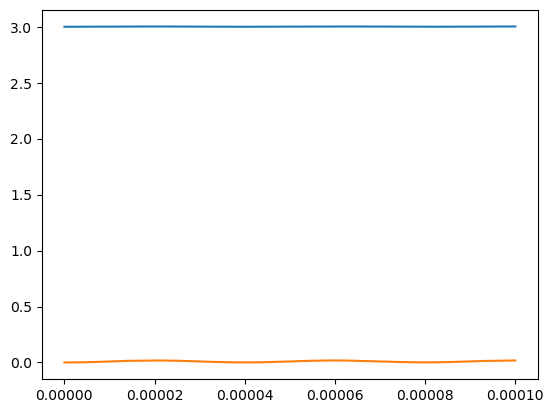

In [73]:
%%time
### INSPECT CONSTITUENT QOBJ RESULTS FROM res_dj ###
th0=res_dj[3];
print(th0);
plt.plot(th0.times, th0.expect[0])
plt.plot(th0.times, th0.expect[1])

# Deprecated

In [128]:
'''
fit func
'''
def exp_func(x, A, k0):
    return A * np.exp(-k0 * x ) + 0.
    # return A * np.exp(k1 * x**2.) + 0.
def fitExp(data):
    try:
        data = np.array(data);
        data_x, data_y = data.transpose();
    except:
        data = np.array(data);
        data_x = data[0,:];
        data_y = data[1,:];

    # guess ampl as first val
    A0 = data_y[0];
    # guess decay constant by linear guess
    kgy = [np.log(data_y)[0], np.log(data_y)[-1]];
    kgx = [data_x[0], data_x[-1]];
    k0 = abs((kgy[1]-kgy[0]) / (kgx[1]-kgx[0])) * 1.;
    # guess offset as min
    # C0 = min(data_y);
    print([A0,k0]);

    # fit and convert covariance matrix to error (1 stdev)
    param_fit, param_cov = curve_fit(
        exp_func, data_x, data_y, p0=[A0,k0]
        # bounds=((0., np.inf), (0., np.inf), (0., np.inf),)
    );
    param_err = np.sqrt(np.diag(param_cov));
    return param_fit, param_err


'''
plot func
'''
def plot_tmp(xaxis_plot_vals, yaxis_plot_vals, rid_num=None, fig_title_string="Scan Results"):
    res_points = yaxis_plot_vals
    res_lineshape = yaxis_plot_vals;
    
    # attempt to fit the result
    try:
        fit_results = fitExp(np.array([xaxis_plot_vals, res_lineshape]).transpose());
    except Exception as e:
        print(repr(e));
        fit_results = np.zeros((2, 3))
    finally:
        # fitted_yvals = np.array([exp_func(x_val, *[1., 0.0008])
        #                          for x_val in xaxis_plot_vals]);
        fitted_yvals = np.array([exp_func(x_val, *fit_results[0])
                                 for x_val in xaxis_plot_vals]);
    
    ### PLOT SPECTRUM ###
    # create figure
    fig_spectrum, axs = plt.subplots(1, 1, layout='constrained')
    if rid_num is not None:
        fig_title_string = "RID: {:d}\n".format(rid_num) + fig_title_string
    
    # plot raw and fitted results
    axs.plot(xaxis_plot_vals, res_lineshape, 'o--', label='Last');
    axs.plot(xaxis_plot_vals, fitted_yvals, '-', label='Exp Fit');
    
    # format plot
    axs.set_title(fig_title_string);
    axs.set_ylabel("State Overlap");
    axs.set_xlabel("Time (us)");
    axs.legend();
    axs.grid(visible=True);
    
    
    ### SHOW PARAMETER TABLE ###
    #axs[1].table(cellText=parameter_df.values, colLabels=parameter_df.keys(), loc='center');
    #axs[1].
    
    ### PRINT HELPER STATISTICS ###
    print("Res: {}".format(fit_results[0]));
    print("Err: {}".format(fit_results[1]));
    # print("Linewidth:\t{:.3f} ms".format(fit_results[0][2]));
    # return fig_spectrum
